<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Alocação de Pessoas em Dormitórios
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

O problema de alocação de dormitórios é um caso clássico de otimização com recursos limitados e restrições de preferência: dado um conjunto de pessoas com primeira e segunda opções de dormitório, como distribuí-las de forma a maximizar a satisfação geral, respeitando a capacidade de cada dormitório? O desafio é que as preferências conflitam entre si, e o conjunto de soluções possíveis cresce fatorialmente com o número de vagas.

Este notebook aplica os quatro algoritmos metaheurísticos implementados no projeto anterior, agora sobre um problema de representação diferente. Enquanto no agendamento de voos cada variável era independente, aqui a solução é uma sequência de escolhas com remoção progressiva de vagas, o que exige uma representação diferente para garantir que nenhuma vaga seja atribuída a duas pessoas ao mesmo tempo.

Os algoritmos são importados do módulo `metaheuristicas.py`, localizado na pasta `../algoritmos/` da subpasta de otimização combinatória. Nenhum algoritmo é reimplementado neste notebook.

As bibliotecas utilizadas são `random` e `numpy` para execução e análise estatística, e `matplotlib` para a comparação visual dos resultados.

Este notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. O Problema e os Dados
3. Representação da Solução e Função de Custo
4. Execução dos Algoritmos
5. Comparação de Resultados
6. Conclusão e Considerações Finais
7. Referências

## 1. Imports e Configurações
O módulo `metaheuristicas` é importado com ajuste de caminho via `sys.path`, apontando para a pasta `algoritmos` na raiz da subpasta de otimização combinatória. As demais bibliotecas são `random` para reprodutibilidade, `numpy` para estatísticas sobre múltiplas execuções e `matplotlib` para visualização comparativa.

In [10]:
import sys
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import session_info
import warnings

sys.path.append(str(Path().resolve().parent))
from Algoritmos import metaheuristicas
from collections import Counter

warnings.filterwarnings('ignore')
session_info.show(dependencies=False)

In [8]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

---

## 2. O Problema e os Dados
Dez estudantes precisam ser alocados em cinco dormitórios, com duas vagas cada. Cada estudante declarou uma primeira e uma segunda preferência de dormitório. O objetivo é encontrar uma alocação que minimize o número de estudantes alocados fora de suas preferências, ponderando pela posição da preferência atendida.

### 2.1 Definição dos dados

Defino os dormitórios disponíveis e as preferências de cada estudante. As preferências são pares ordenados: o primeiro elemento é a primeira opção e o segundo é a segunda opção.

In [9]:
dormitorios = ['Dormitório 1', 'Dormitório 2', 'Dormitório 3', 'Dormitório 4', 'Dormitório 5']

preferencias = [
    ('Amanda',  ('Dormitório 4', 'Dormitório 3')),
    ('Pedro',   ('Dormitório 1', 'Dormitório 5')),
    ('Marcos',  ('Dormitório 2', 'Dormitório 1')),
    ('Priscila',('Dormitório 1', 'Dormitório 5')),
    ('Jessica', ('Dormitório 2', 'Dormitório 4')),
    ('Paulo',   ('Dormitório 3', 'Dormitório 5')),
    ('Fred',    ('Dormitório 5', 'Dormitório 2')),
    ('Suzana',  ('Dormitório 4', 'Dormitório 3')),
    ('Laura',   ('Dormitório 4', 'Dormitório 3')),
    ('Ricardo', ('Dormitório 3', 'Dormitório 2')),
]

print(f"Dormitórios  : {len(dormitorios)}  ({', '.join(dormitorios)})")
print(f"Estudantes   : {len(preferencias)}")
print(f"Vagas totais : {len(dormitorios) * 2}")

Dormitórios  : 5  (Dormitório 1, Dormitório 2, Dormitório 3, Dormitório 4, Dormitório 5)
Estudantes   : 10
Vagas totais : 10


### 2.2 Análise de conflitos de preferência
Antes de executar qualquer algoritmo, verifico quantos estudantes concorrem ao mesmo dormitório como primeira opção. Isso revela onde os conflitos são inevitáveis e antecipa quais dormitórios terão mais disputas.

In [11]:
primeiras = Counter(p[1][0] for p in preferencias)
segundas  = Counter(p[1][1] for p in preferencias)

print(f"{'Dormitório':<12}  {'1ª opção':>9}  {'2ª opção':>9}  {'Vagas':>6}  {'Demanda total':>14}")
print("-" * 58)
for d in dormitorios:
    p1     = primeiras.get(d, 0)
    p2     = segundas.get(d, 0)
    demanda = p1 + p2
    print(f"{d:<12}  {p1:>9}  {p2:>9}  {2:>6}  {demanda:>14}")

Dormitório     1ª opção   2ª opção   Vagas   Demanda total
----------------------------------------------------------
Dormitório 1          2          1       2               3
Dormitório 2          2          2       2               4
Dormitório 3          2          3       2               5
Dormitório 4          3          1       2               4
Dormitório 5          1          3       2               4


O dormitório 4 concentra três primeiras opções para apenas duas vagas, o que torna inevitável que ao menos um estudante seja alocado fora de sua primeira escolha. O dormitório 3 enfrenta situação semelhante como segunda opção. Essa assimetria é a principal fonte de dificuldade do problema: qualquer solução ótima já parte de um custo mínimo não nulo.

### 2.3 Visualização das preferências
Visualizo a distribuição de demanda por dormitório em relação à capacidade disponível. A linha tracejada marca o limite de duas vagas por dormitório.

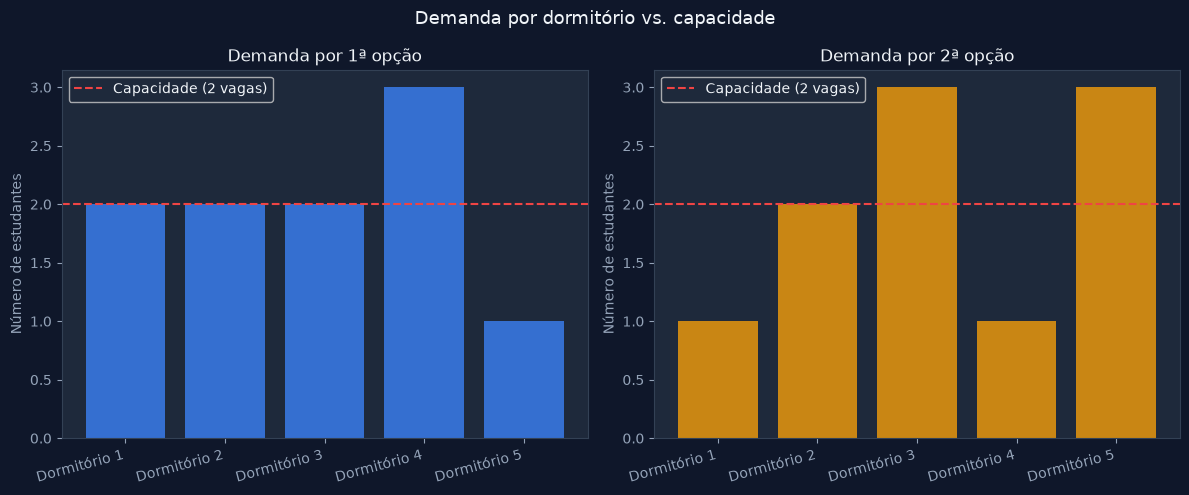

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x      = range(len(dormitorios))
p1_vals = [primeiras.get(d, 0) for d in dormitorios]
p2_vals = [segundas.get(d, 0)  for d in dormitorios]

for ax, vals, titulo, cor in zip(
    axes,
    [p1_vals, p2_vals],
    ['Demanda por 1ª opção', 'Demanda por 2ª opção'],
    ['#3b82f6', '#f59e0b']
):
    ax.bar(x, vals, color=cor, alpha=0.8)
    ax.axhline(2, color='#ef4444', linestyle='--', linewidth=1.5, label='Capacidade (2 vagas)')
    ax.set_xticks(x)
    ax.set_xticklabels(dormitorios, rotation=15, ha='right')
    ax.set_ylabel('Número de estudantes')
    ax.set_title(titulo)
    ax.legend()

plt.suptitle('Demanda por dormitório vs. capacidade', fontsize=13)
plt.tight_layout()
plt.show()

> O gráfico confirma o desequilíbrio identificado na tabela: o Dormitório 4 concentra três primeiras opções para apenas duas vagas, tornando inevitável ao menos uma insatisfação. Os dormitórios 1 e 2 também atingem o limite de demanda primária. O Dormitório 5, com apenas uma primeira opção, é o que oferece maior folga de alocação.

---

## 3. Representação da Solução e Função de Custo

Este problema exige uma representação diferente do notebook de voos. Lá, cada variável era independente: o voo escolhido para uma pessoa não afetava as opções disponíveis para outra. Aqui, as vagas são limitadas: uma vez que dois estudantes ocupam um dormitório, ele está cheio e não pode receber mais ninguém.

### 3.1 Representação por índice com remoção progressiva


A solução é representada como uma sequência de índices que referenciam uma lista de vagas disponíveis que encolhe a cada atribuição. No início há 10 vagas, representadas como dois índices por dormitório: `[0, 0, 1, 1, 2, 2, 3, 3, 4, 4]`. Ao atribuir a primeira pessoa, escolhemos um índice entre 0 e 9 e removemos a vaga correspondente. Para a segunda pessoa, escolhemos entre 0 e 8, e assim por diante.

Essa representação garante que nenhuma vaga seja atribuída duas vezes, sem precisar de nenhuma lógica de correção após a geração da solução.

O domínio reflete esse encolhimento: a primeira variável tem domínio `(0, 9)`, a segunda `(0, 8)`, até a última com domínio `(0, 0)`.

In [13]:
dominio = [(0, (len(dormitorios) * 2) - i - 1) for i in range(len(dormitorios) * 2)]

print(f"Variáveis de decisão : {len(dominio)}")
print(f"Domínio por posição  : {dominio}")
print(f"Soluções possíveis   : {eval('*'.join(str(d[1]-d[0]+1) for d in dominio)):,}")

Variáveis de decisão : 10
Domínio por posição  : [(0, 9), (0, 8), (0, 7), (0, 6), (0, 5), (0, 4), (0, 3), (0, 2), (0, 1), (0, 0)]
Soluções possíveis   : 3,628,800


### 3.2 Função de decodificação

A função `imprimir_solucao` decodifica um vetor de índices em alocações legíveis. A cada passo, ela consulta a lista de vagas restantes, identifica o dormitório correspondente ao índice escolhido e remove aquela vaga da lista.

In [14]:
def imprimir_solucao(solucao):
    vagas = []
    for i in range(len(dormitorios)):
        vagas += [i, i]
    print(f"{'Estudante':<12}  {'Dormitório':<12}  {'Resultado'}")
    print("-" * 42)
    for i in range(len(solucao)):
        idx        = solucao[i]
        dormitorio = dormitorios[vagas[idx]]
        nome       = preferencias[i][0]
        pref       = preferencias[i][1]
        if pref[0] == dormitorio:
            resultado = '1ª opção'
        elif pref[1] == dormitorio:
            resultado = '2ª opção'
        else:
            resultado = 'fora das preferências'
        print(f"{nome:<12}  {dormitorio:<12}  {resultado}")
        del vagas[idx]

In [15]:
# exemplo de solução manual do curso
solucao_exemplo = [6, 1, 2, 1, 2, 0, 2, 2, 0, 0]
imprimir_solucao(solucao_exemplo)

Estudante     Dormitório    Resultado
------------------------------------------
Amanda        Dormitório 4  1ª opção
Pedro         Dormitório 1  1ª opção
Marcos        Dormitório 2  1ª opção
Priscila      Dormitório 2  fora das preferências
Jessica       Dormitório 3  fora das preferências
Paulo         Dormitório 1  fora das preferências
Fred          Dormitório 5  1ª opção
Suzana        Dormitório 5  fora das preferências
Laura         Dormitório 3  2ª opção
Ricardo       Dormitório 4  fora das preferências


### 3.3 Função de custo

A função de custo atribui penalidades por insatisfação: 0 para primeira opção atendida, 1 para segunda opção atendida e 3 para alocação fora das preferências declaradas. O objetivo dos algoritmos é minimizar a soma dessas penalidades sobre todos os estudantes. O custo mínimo possível depende dos conflitos estruturais do problema e não necessariamente é zero.

In [16]:
def funcao_custo(solucao):
    custo = 0
    vagas = []
    for i in range(len(dormitorios)):
        vagas += [i, i]

    for i in range(len(solucao)):
        idx        = solucao[i]
        dormitorio = dormitorios[vagas[idx]]
        pref       = preferencias[i][1]

        if pref[0] == dormitorio:
            custo += 0
        elif pref[1] == dormitorio:
            custo += 1
        else:
            custo += 3

        del vagas[idx]

    return custo

In [17]:
custo_exemplo = funcao_custo(solucao_exemplo)
print(f"Custo da solução exemplo : {custo_exemplo}")

Custo da solução exemplo : 16


O custo da solução exemplo serve de referência inicial. Os algoritmos buscarão soluções com custo igual ou menor ao longo das execuções.

---

## 4. Execução dos Algoritmos

Executo os quatro algoritmos com a mesma função de custo e o mesmo domínio. O padrão de chamada é idêntico ao notebook de voos, pois os algoritmos são genéricos e não conhecem nada sobre dormitórios ou preferências.

### 4.1 Pesquisa Aleatória

A pesquisa aleatória amostra soluções uniformemente no espaço de busca e retorna a de menor custo após 10.000 iterações. Com cerca de 3,6 milhões de soluções possíveis, a cobertura é parcial mas suficiente para estabelecer uma linha de base.

In [18]:
solucao_aleatoria = metaheuristicas.pesquisa_aleatoria(dominio, funcao_custo)
print(f"Custo (pesquisa aleatória) : {funcao_custo(solucao_aleatoria)}")
imprimir_solucao(solucao_aleatoria)

Custo (pesquisa aleatória) : 4
Estudante     Dormitório    Resultado
------------------------------------------
Amanda        Dormitório 4  1ª opção
Pedro         Dormitório 5  2ª opção
Marcos        Dormitório 1  2ª opção
Priscila      Dormitório 1  1ª opção
Jessica       Dormitório 2  1ª opção
Paulo         Dormitório 3  1ª opção
Fred          Dormitório 5  1ª opção
Suzana        Dormitório 4  1ª opção
Laura         Dormitório 3  2ª opção
Ricardo       Dormitório 2  2ª opção


### 4.2 Subida da Encosta

A subida da encosta parte de uma solução aleatória e move-se para o vizinho de menor custo até convergir para um ótimo local. Em problemas com poucos ótimos locais e espaço de busca pequeno, tende a ser competitiva. Com um espaço de apenas 3,6 milhões de soluções, o risco de ficar preso em regiões ruins é menor do que no problema de voos.

In [20]:
solucao_encosta = metaheuristicas.subida_encosta(dominio, funcao_custo)
print(f"Custo (subida da encosta) : {funcao_custo(solucao_encosta)}")
imprimir_solucao(solucao_encosta)

Custo (subida da encosta) : 5
Estudante     Dormitório    Resultado
------------------------------------------
Amanda        Dormitório 4  1ª opção
Pedro         Dormitório 1  1ª opção
Marcos        Dormitório 2  1ª opção
Priscila      Dormitório 1  1ª opção
Jessica       Dormitório 4  2ª opção
Paulo         Dormitório 5  2ª opção
Fred          Dormitório 5  1ª opção
Suzana        Dormitório 3  2ª opção
Laura         Dormitório 3  2ª opção
Ricardo       Dormitório 2  2ª opção


### 4.3 Têmpera Simulada

A têmpera simulada perturba a solução iterativamente, aceitando pioras com probabilidade decrescente. O mecanismo de escape de ótimos locais é seu principal diferencial em relação à subida da encosta, especialmente em problemas com paisagens de custo irregulares.

In [21]:
solucao_tempera = metaheuristicas.tempera_simulada(dominio, funcao_custo)
print(f"Custo (têmpera simulada) : {funcao_custo(solucao_tempera)}")
imprimir_solucao(solucao_tempera)

Custo (têmpera simulada) : 7
Estudante     Dormitório    Resultado
------------------------------------------
Amanda        Dormitório 2  fora das preferências
Pedro         Dormitório 1  1ª opção
Marcos        Dormitório 2  1ª opção
Priscila      Dormitório 1  1ª opção
Jessica       Dormitório 4  2ª opção
Paulo         Dormitório 3  1ª opção
Fred          Dormitório 5  1ª opção
Suzana        Dormitório 4  1ª opção
Laura         Dormitório 5  fora das preferências
Ricardo       Dormitório 3  1ª opção


### 4.4 Algoritmo Genético

O algoritmo genético evolui uma população de 100 soluções ao longo de 500 gerações com elitismo de 20% e probabilidade de mutação de 20%. A busca populacional permite explorar regiões distintas do espaço simultaneamente, o que favorece a convergência para soluções de melhor qualidade.

In [22]:
solucao_genetico = metaheuristicas.algoritmo_genetico(dominio, funcao_custo)
print(f"Custo (algoritmo genético) : {funcao_custo(solucao_genetico)}")
imprimir_solucao(solucao_genetico)

Custo (algoritmo genético) : 5
Estudante     Dormitório    Resultado
------------------------------------------
Amanda        Dormitório 3  2ª opção
Pedro         Dormitório 1  1ª opção
Marcos        Dormitório 2  1ª opção
Priscila      Dormitório 5  2ª opção
Jessica       Dormitório 2  1ª opção
Paulo         Dormitório 1  fora das preferências
Fred          Dormitório 5  1ª opção
Suzana        Dormitório 4  1ª opção
Laura         Dormitório 4  1ª opção
Ricardo       Dormitório 3  1ª opção


---

## 5. Comparação de Resultados
Assim como no notebook de voos, uma única execução não é base suficiente para comparação. Realizo 10 execuções independentes de cada algoritmo e analiso a distribuição dos custos obtidos.

### 5.1 Execução das rodadas

In [24]:
N_RODADAS = 10
random.seed(42)

resultados = {
    'Pesquisa Aleatória' : [],
    'Subida da Encosta'  : [],
    'Têmpera Simulada'   : [],
    'Algoritmo Genético' : [],
}

for rodada in range(N_RODADAS):
    resultados['Pesquisa Aleatória'].append(
        funcao_custo(metaheuristicas.pesquisa_aleatoria(dominio, funcao_custo))
    )
    resultados['Subida da Encosta'].append(
        funcao_custo(metaheuristicas.subida_encosta(dominio, funcao_custo))
    )
    resultados['Têmpera Simulada'].append(
        funcao_custo(metaheuristicas.tempera_simulada(dominio, funcao_custo))
    )
    resultados['Algoritmo Genético'].append(
        funcao_custo(metaheuristicas.algoritmo_genetico(dominio, funcao_custo))
    )
    print(f"Rodada {rodada + 1:2d} concluída.")

Rodada  1 concluída.
Rodada  2 concluída.
Rodada  3 concluída.
Rodada  4 concluída.
Rodada  5 concluída.
Rodada  6 concluída.
Rodada  7 concluída.
Rodada  8 concluída.
Rodada  9 concluída.
Rodada 10 concluída.


### 5.2 Tabela de resultados

In [25]:
print(f"{'Algoritmo':<22} {'Média':>8} {'Mínimo':>8} {'Máximo':>8} {'Desvio':>8}")
print("-" * 58)
for nome, custos in resultados.items():
    arr = np.array(custos)
    print(f"{nome:<22} {arr.mean():>8.1f} {arr.min():>8.0f} {arr.max():>8.0f} {arr.std():>8.1f}")

Algoritmo                 Média   Mínimo   Máximo   Desvio
----------------------------------------------------------
Pesquisa Aleatória          3.1        2        5      1.1
Subida da Encosta          13.1        8       16      2.8
Têmpera Simulada           10.8        4       17      4.6
Algoritmo Genético          3.2        2        5      1.2


### 5.3 Boxplot comparativo

O boxplot permite visualizar a distribuição completa dos custos por algoritmo. Neste problema, com escala de custo muito menor do que no problema de voos, diferenças pequenas em valor absoluto podem representar impactos significativos em satisfação.

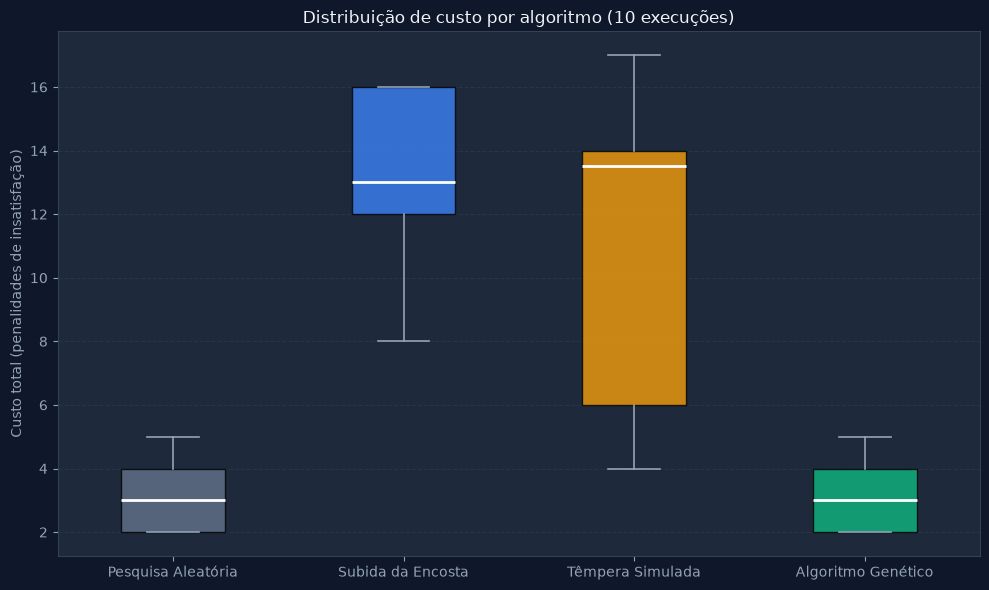

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

nomes = list(resultados.keys())
dados = [resultados[n] for n in nomes]
cores = ['#64748b', '#3b82f6', '#f59e0b', '#10b981']

bp = ax.boxplot(dados, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)

for elemento in ['whiskers', 'caps', 'fliers']:
    for item in bp[elemento]:
        item.set(color='#94a3b8', linewidth=1.2)

ax.set_xticklabels(nomes, fontsize=10)
ax.set_ylabel('Custo total (penalidades de insatisfação)')
ax.set_title('Distribuição de custo por algoritmo (10 execuções)', fontsize=12)
ax.yaxis.grid(True)
plt.tight_layout()
plt.show()

> O resultado mais surpreendente desta comparação é a inversão em relação ao notebook de voos: a pesquisa aleatória e o algoritmo genético convergem para custos médios praticamente idênticos (3.1 e 3.2), enquanto a subida da encosta apresenta o pior desempenho médio, com custo 13.1 e desvio de 2.8. A têmpera simulada, apesar de atingir o custo 4 em sua melhor execução, apresenta a maior variância de todas, com pior caso de 17. Esse padrão sugere que a paisagem de custo deste problema tem muitos ótimos locais rasos, o que penaliza algoritmos de vizinhança pura e favorece a exploração ampla do espaço que a pesquisa aleatória realiza naturalmente em 10.000 iterações.

---

## 6. Conclusão e Considerações Finais

### 6.1 Síntese do Projeto

Apliquei os quatro algoritmos metaheurísticos ao problema de alocação de estudantes em dormitórios, um problema estruturalmente diferente do agendamento de voos: o espaço de soluções é menor, a representação é baseada em permutação com remoção progressiva de vagas, e a função de custo mede insatisfação de preferências em vez de custo financeiro e tempo.

A comparação em 10 execuções independentes produziu os seguintes resultados:

| Algoritmo          | Custo médio | Melhor custo | Pior custo | Desvio padrão |
|--------------------|-------------|--------------|------------|---------------|
|Pesquisa Aleatória          |3.1        |2        |5|      1.1|
|Subida da Encosta          |13.1        |8       |16|      2.8|
|Têmpera Simulada           |10.8        |4       |17|      4.6|
|Algoritmo Genético          |3.2        |2        |5|      1.2|

### 6.2 Relevantes

A representação por índice com remoção progressiva é o aspecto técnico mais relevante deste notebook. Ela resolve o problema de colisão de vagas sem nenhuma lógica de reparação pós-geração: a solução é válida por construção. A consequência é que o domínio não é uniforme, cada posição tem um intervalo diferente, o que os algoritmos precisam respeitar ao explorar vizinhanças e gerar mutações. O módulo `metaheuristicas.py` suporta isso naturalmente porque opera sobre o vetor de domínio variável, não sobre um domínio fixo.

Vale também observar que o custo mínimo possível neste problema não é zero. Com três estudantes concorrendo às duas vagas do Dormitório 4 como primeira opção, pelo menos um deles necessariamente recebe penalidade. Isso significa que a comparação entre algoritmos deve ser feita em termos relativos ao custo mínimo atingível, não em relação ao zero absoluto.

### 6.3 Limitações e Considerações

O problema é sintético, com preferências definidas manualmente e capacidade fixa de duas vagas por dormitório. Em cenários reais, preferências poderiam incluir restrições adicionais como compatibilidade entre colegas de quarto, orçamento ou proximidade de aulas. A função de custo assume pesos fixos de 0, 1 e 3 para primeira opção, segunda opção e fora das preferências, sem calibração por importância relativa de cada estudante ou dormitório. Este notebook tem finalidade exclusivamente educacional e complementa o estudo iniciado no notebook de agendamento de voos, demonstrando que os mesmos algoritmos se adaptam a problemas de natureza estruturalmente distinta.

---

## 7. Referências

- GRANATYR, Jones. *Algoritmos de Otimização em Python*. IAExpert Academy. Disponível em: https://iaexpert.academy/cursos-online-assinatura/inteligencia-artificial-algoritmos-otimizacao-python/
- SEGARAN, Toby. *Programming Collective Intelligence*. O'Reilly Media, 2007.
- Documentação oficial Python: módulo `random`. Disponível em: https://docs.python.org/3/library/random.html

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Algoritmos de Otimização em Python](https://iaexpert.academy/cursos-online-assinatura/inteligencia-artificial-algoritmos-otimizacao-python/),
> da IAExpert Academy, para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.